In [1]:
# %load_ext autoreload
# %autoreload 2

from pathlib import Path
import psutil
import datetime


from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, signal

# from astropy import units
import tqdm
import polars as pl
from tqdm.notebook import tqdm as tqdm_notebook

from centrex_tlf import states, couplings, utils
from centrex_tlf.states import UncoupledBasisState, UncoupledState, ElectronicState
from state_prep.utils import calculate_transition_frequency
from state_prep.electric_fields import (
    ElectricField,
    Ez_from_csv,
)
from state_prep.hamiltonians import SlowHamiltonian
from state_prep.intensity_profiles import GaussianBeam, BackgroundField
from state_prep.magnetic_fields import MagneticField
from state_prep.microwaves import Polarization, MicrowaveField
from state_prep.simulator import Simulator
from state_prep.trajectory import Trajectory


In [2]:
plt.rcParams.update({"font.size": 14})

In [3]:
cwd = Path().cwd().absolute()
path_data = cwd / "results"


In [4]:
nr_cores = psutil.cpu_count(logical=False) + 2

rng = np.random.default_rng()


In [5]:
common_offset = 26.669e9  # Hz
measured_resonance = 26.6684e9  # Hz

## Define molecule trajectory
Defining the molecule trajectory as a Trajectory object. Specifying the initial position as z = 50 mm, i.e. 50mm  after the center of the microwaves is, and on the axis of the beamline. Taking the beam velocity to be 200 m/s in the z-direction. The simulation ends when `zfin` is reached, 200 mm from the microwwaves.

In [6]:
trajectory = Trajectory(
    Rini=np.array((0, 0, -80e-3)), Vini=np.array((0, 0, 200.0)), zfin=200e-3
)

## Define electric field
Defining an electric field that is an approximation of what the molecules should see in the real experiment.

In [7]:
# Define electric field based on finite element simulations
Ez = Ez_from_csv()
E_R = lambda R: np.array([0, 0, Ez(R[2])])


electric_field = ElectricField(E_R, trajectory.R_t)

Max electric field: 263.46 V/cm
Electric field at z = 1.125'': 109.24 V/cm


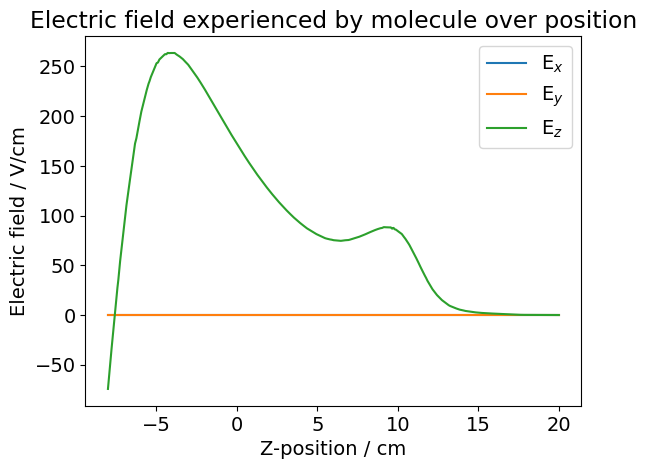

In [8]:
# Plot the electric field as a check:
ts, Es, ax = electric_field.plot(trajectory, position=True)

print(f"Max electric field: {np.max(Es):.2f} V/cm")
print(
    f"Electric field at z = 1.125'': {E_R(np.array([0, 0, 0.0254 * 1.125]))[2]:.2f} V/cm"
)

## Define magnetic field
Define the magnetic field. Using a constant field, either a nominal small field (so mF states become non-degenerate eigenstates of the Hamiltonian) or something resembilng Earth's magnetic field.

In [9]:
B = np.array((0, 0, 1e-3))


# B = np.array((0.2,0.45,0.1))
def B_R(R):
    if len(R.shape) == 1:
        return B
    else:
        return B.reshape((3, 1)) * np.ones(R.shape)


magnetic_field = MagneticField(B_R, R_t=trajectory.R_t)

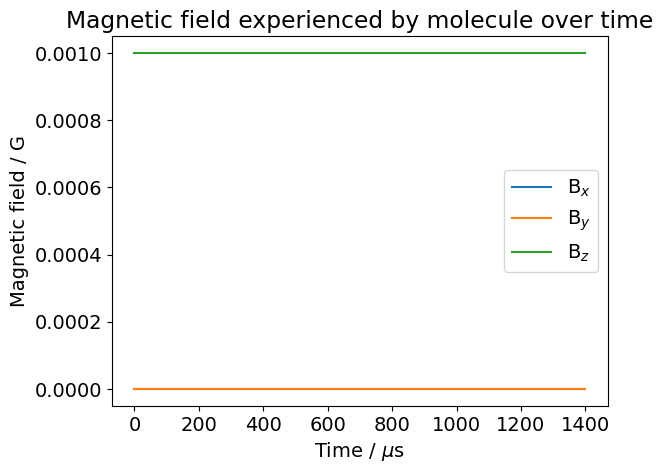

In [10]:
magnetic_field.plot(trajectory)

## Initial and final states
Define approximate initial states here.

In [11]:
# Define some useful approximate states
J0_singlet = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=0,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=+1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        - 1
        * UncoupledBasisState(
            J=0,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=+1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J0_triplet_0 = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=0,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=+1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        + 1
        * UncoupledBasisState(
            J=0,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=+1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J0_triplet_p = 1 * UncoupledBasisState(
    J=0,
    mJ=0,
    I1=1 / 2,
    m1=1 / 2,
    I2=1 / 2,
    m2=1 / 2,
    P=+1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

J0_triplet_m = 1 * UncoupledBasisState(
    J=0,
    mJ=0,
    I1=1 / 2,
    m1=-1 / 2,
    I2=1 / 2,
    m2=-1 / 2,
    P=+1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

# initial_states_approx = [J0_singlet, J0_triplet_m, J0_triplet_0, J0_triplet_p]

In [12]:
# Define some useful approximate states
J1_singlet = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=1,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=-1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        - 1
        * UncoupledBasisState(
            J=1,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=-1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J1_triplet_0 = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=1,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=-1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        + 1
        * UncoupledBasisState(
            J=1,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=-1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J1_triplet_p = 1 * UncoupledBasisState(
    J=1,
    mJ=0,
    I1=1 / 2,
    m1=1 / 2,
    I2=1 / 2,
    m2=1 / 2,
    P=-1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

J1_triplet_m = 1 * UncoupledBasisState(
    J=1,
    mJ=0,
    I1=1 / 2,
    m1=-1 / 2,
    I2=1 / 2,
    m2=-1 / 2,
    P=-1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

initial_states_approx = [J1_singlet, J1_triplet_m, J1_triplet_0, J1_triplet_p]

In [13]:
# Define some useful approximate states
J2_singlet = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=2,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        - 1
        * UncoupledBasisState(
            J=2,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J2_triplet_0 = (
    1
    / np.sqrt(2)
    * (
        1
        * UncoupledBasisState(
            J=2,
            mJ=0,
            I1=1 / 2,
            m1=1 / 2,
            I2=1 / 2,
            m2=-1 / 2,
            P=1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
        + 1
        * UncoupledBasisState(
            J=2,
            mJ=0,
            I1=1 / 2,
            m1=-1 / 2,
            I2=1 / 2,
            m2=1 / 2,
            P=1,
            Omega=0,
            electronic_state=ElectronicState.X,
        )
    )
)

J2_triplet_p = 1 * UncoupledBasisState(
    J=2,
    mJ=0,
    I1=1 / 2,
    m1=1 / 2,
    I2=1 / 2,
    m2=1 / 2,
    P=1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

J2_triplet_m = 1 * UncoupledBasisState(
    J=2,
    mJ=0,
    I1=1 / 2,
    m1=-1 / 2,
    I2=1 / 2,
    m2=-1 / 2,
    P=1,
    Omega=0,
    electronic_state=ElectronicState.X,
)

final_states_approx = [J2_singlet, J2_triplet_m, J2_triplet_0, J2_triplet_p]

## Define molecule trajectory
Defining the molecule trajectory as a Trajectory object. Specifying the initial position as z = 50 mm, i.e. 50mm  after the center of the microwaves is, and on the axis of the beamline. Taking the beam velocity to be 200 m/s in the z-direction. The simulation ends when `zfin` is reached, 200 mm from the microwwaves.

In [14]:
trajectory = Trajectory(
    Rini=np.array((0, 0, -80e-3)), Vini=np.array((0, 0, 184.0)), zfin=200e-3
)

## Define slowly varying Hamiltonian
Define a Hamiltonian object that represents the slowly varying part of the Hamiltonian (i.e. everything except the microwaves). Using J = 0-3 here since we're interested in the time-evolution of J = 0 and 1 states; J = 0 and 3 are absolutely required since the electric field couples J = 0 to these, J = 3 is not strictly necessary. Since the Stark energies are << the rotational energies, we mostly just need the J of interest $\pm 1$.

In [15]:
Js = [0, 1, 2, 3]
hamiltonian = SlowHamiltonian(Js, trajectory, electric_field, magnetic_field)
# hamiltonian = SlowHamiltonianOld(0, 3, trajectory, electric_field, magnetic_field, '../hamiltonians/TlF_X_state_hamiltonian0to3_2020_03_03.pickle')

### J = 1 to 2 microwaves

In [16]:
# Define states
state1 = J1_triplet_0
state2 = J2_triplet_0

# Center position
R0 = np.array((0.00, 0, 0.0254 * 1.125))

#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p_main = p_z
P_R = lambda R: p_main / np.sqrt(np.sum(p_main**2))

# Define k-vector
k = np.array((1, 0, 0))
pol = Polarization(P_R, k, f_long=1)

#### Frequency
# Calculate the microwave frequency between specified states at a specific point
muW_freq_2 = calculate_transition_frequency(
    state1, state2, hamiltonian.H_R(R0), hamiltonian.QN
)
print(f"Transition frequency at center of SPA2 microwaves: {muW_freq_2 / 1e9:.5f} GHz")

#### Intensity profile:
# Define a Gaussian intensity profile
intensity = GaussianBeam(
    power=0.5e-3,
    sigma=25.4e-3 / (2 * np.sqrt(2 * np.log(2))),
    R0=R0,
    k=k,
    freq=muW_freq_2,
)

#### Define MicrowaveField
mf12 = MicrowaveField(1, 2, intensity, pol, muW_freq_2, QN=hamiltonian.QN)

Transition frequency at center of SPA2 microwaves: 26.66881 GHz


### J = 1 to 2 background field
Defining a field that has uniform intensity everywhere to represent microwaves randomly scattering of the vacuum chamber, windows etc

In [17]:
#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p = p_z + 0.4 * p_y
P_R = lambda R: p / np.sqrt(np.sum(p**2))


pol_bg = Polarization(P_R)

#### Intensity profile:
# Define a Gaussian intensity profile
lims = [
    (-1, 1),
    (-1, 1),
    (-1, 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

# Scan J12 frequency with BG field Z pol

## Constant BG intensity

In [18]:
#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p = p_z
P_R = lambda R: p / np.sqrt(np.sum(p**2))


pol_bg = Polarization(P_R)

#### Intensity profile:
# Define a Gaussian intensity profile
lims = [
    (-1, 1),
    (-1, 1),
    (-1, 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

In [19]:
def run_simulation(
    power_spa2: float,
    bg_fraction: float,
    freq_spa2: float,
    v_forward: float,
    initial_state_idx: int,
    initial_states_approx: list[states.UncoupledState],
    target_state: states.UncoupledState | list[states.UncoupledState],
    monitor_states: list[states.UncoupledState] = [],
    N_steps=10_000,
) -> tuple[float, float, float, float, float, float, list[float]]:
    """
    Runs the simulation for one value of power and finds the probability of ending up in the target state.
    """

    mf12.set_frequency(freq_spa2)
    mf12_bg.set_frequency(freq_spa2)

    # set powers & intensities
    mf12.set_power(power_spa2)
    mf12_bg.intensity.intensity = (
        mf12.intensity.I_R(np.array([0.00, 0, 0.0254 * 1.125])) * bg_fraction
    )

    # Run the simulator
    microwave_fields = [mf12, mf12_bg]

    # # trajectories
    trajectory.Vini[-1] = v_forward

    # pickle problem occurs here
    simulator = Simulator(
        trajectory,
        electric_field,
        magnetic_field,
        initial_states_approx,
        hamiltonian,
        microwave_fields,
    )

    result = simulator.run(
        N_steps=N_steps,
        store_energies=False,
        store_psis=False,
        store_probabilities=False,
        progress=False,
    )

    # Determine probability to be in initial state
    prob_ini = float(
        result.get_state_probability(
            result.initial_states[initial_state_idx],
            initial_state=result.initial_states[initial_state_idx],
        )[-1]
    )

    # Determine probability to be in target state
    if isinstance(target_state, states.UncoupledState):
        target_state = [target_state]
    prob_fin = 0.0
    for ts in target_state:
        prob_fin += float(
            result.get_state_probability(
                ts, initial_state=result.initial_states[initial_state_idx]
            )[-1]
        )

    prob_monitor_states = []
    for monitor_state in monitor_states:
        prob_monitor_states.append(
            float(
                result.get_state_probability(
                    monitor_state,
                    initial_state=result.initial_states[initial_state_idx],
                )[-1]
            )
        )

    return (
        power_spa2,
        bg_fraction,
        freq_spa2,
        v_forward,
        prob_ini,
        prob_fin,
        prob_monitor_states,
    )

In [20]:
monitor_states = [
    J2_singlet,
    states.CoupledBasisState(
        J=2,
        F1=3 / 2,
        F=1,
        mF=0,
        electronic_state=ElectronicState.X,
        I1=1 / 2,
        I2=1 / 2,
        P=1,
    ).transform_to_uncoupled(),
    J2_triplet_m,
    J2_triplet_p,
]

In [21]:
detunings = np.linspace(-2e6, 1.5e6, 25)

res = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation)(
        power_spa2=5e-5,
        bg_fraction=1 / 35,
        freq_spa2=detuning + muW_freq_2,
        v_forward=184.0,
        initial_state_idx=2,  # J1_triplet_0
        initial_states_approx=initial_states_approx,
        target_state=J2_triplet_0,
        monitor_states=monitor_states,
    )
    for detuning in detunings
)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   36.7s finished
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   36.7s finished


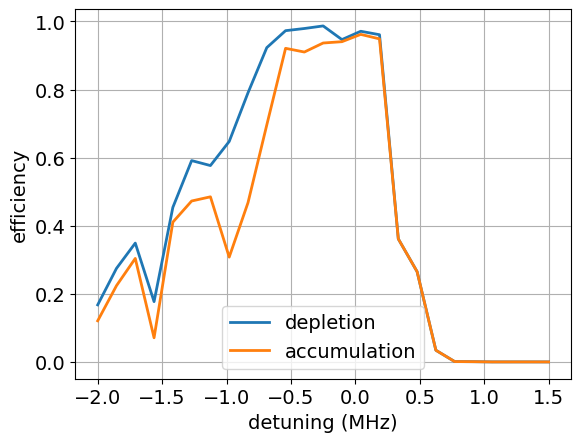

In [22]:
fig, ax = plt.subplots()

ax.plot(detunings / 1e6, [1 - r[-3] for r in res], lw=2, label="depletion")
ax.plot(detunings / 1e6, [r[-2] for r in res], lw=2, label="accumulation")

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend()
ax.grid()

In [ ]:
from state_prep.utils import find_max_overlap_idx


def run_simulation_batch(
    power_spa2: np.ndarray,
    bg_fraction: np.ndarray,
    detunings: np.ndarray,
    v_forward: float,
    initial_state_idx: int,
    initial_states_approx: list[states.UncoupledState],
    target_state: states.UncoupledState | list[states.UncoupledState],
    monitor_states: list[states.UncoupledState] = [],
    N_steps=10_000,
) -> tuple[float, float, float, float, float, float, list[float]]:
    """
    Runs the simulation for one value of power and finds the probability of ending up in the target state.
    """

    mf12.set_frequency(muW_freq_2)
    mf12_bg.set_frequency(muW_freq_2)

    # set powers & intensities
    mf12.set_power(power_spa2[0])
    mf12_bg.intensity.intensity = (
        mf12.intensity.I_R(np.array([0.00, 0, 0.0254 * 1.125])) * bg_fraction[0]
    )

    # Run the simulator
    microwave_fields = [mf12, mf12_bg]

    # # trajectories
    trajectory.Vini[-1] = v_forward

    # pickle problem occurs here
    simulator = Simulator(
        trajectory,
        electric_field,
        magnetic_field,
        initial_states_approx,
        hamiltonian,
        microwave_fields,
    )

    intensity_prefactors = np.array(
        [power_spa2 / power_spa2[0], bg_fraction / bg_fraction[0]]
    ).T

    result = simulator.run_microwave_scan(
        detunings_hz=detunings,
        intensity_prefactors=intensity_prefactors,
        N_steps=N_steps,
        monitor_states=monitor_states,
        progress=False,
    )

    init_idx = find_max_overlap_idx(
        initial_states_approx[initial_state_idx].state_vector, result.V_ini
    )
    prob_ini = result.probabilities_final[:, initial_state_idx, init_idx]

    # Determine probability to be in target state
    if isinstance(target_state, states.UncoupledState):
        target_state = [target_state]

    prob_fin = np.zeros(len(power_spa2))
    for ts in target_state:
        final_idx = find_max_overlap_idx(ts.state_vector, result.V_ini)
        prob_fin += result.probabilities_final[:, initial_state_idx, final_idx]

    prob_monitor_states = []
    for monitor_state in monitor_states:
        monitor_idx = find_max_overlap_idx(monitor_state.state_vector, result.V_ini)
        prob_monitor_states.append(
            result.probabilities_final[:, initial_state_idx, monitor_idx]
        )

    return (
        power_spa2,
        bg_fraction,
        detunings,
        v_forward,
        prob_ini,
        prob_fin,
        prob_monitor_states,
    )

In [34]:
detunings_batch = np.array([detunings, detunings]).T
res_batch = run_simulation_batch(
    np.ones(detunings.shape) * 5e-5,
    np.ones(detunings.shape) * 1 / 35,
    detunings_batch,
    184,
    2,
    initial_states_approx,
    J2_triplet_0,
    monitor_states,
)

In [ ]:
fig, ax = plt.subplots()

ax.plot(detunings / 1e6, [1 - r[-3] for r in res], lw=2, label="depletion")
ax.plot(detunings / 1e6, [r[-2] for r in res], lw=2, label="accumulation")

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend()
ax.grid()

In [60]:
res_batch.probabilities_final[12, 2, :]

array([7.58244960e-25, 6.49453165e-07, 2.19015836e-24, 2.92772554e-13,
       5.31553041e-06, 2.77292540e-10, 2.42445286e-20, 6.23504607e-21,
       3.80852617e-19, 1.21485357e-19, 2.65965022e-22, 2.64988883e-20,
       5.57036000e-20, 1.00777142e-11, 1.30432532e-02, 7.24904218e-10,
       3.58684321e-19, 4.44448205e-18, 1.25356717e-20, 2.13580992e-19,
       5.01750895e-02, 7.64870103e-19, 1.97709855e-19, 1.54490411e-09,
       1.75340512e-20, 2.67344178e-20, 5.53061982e-21, 4.16208233e-20,
       1.73112426e-19, 1.43228883e-16, 2.04457335e-20, 4.99426304e-20,
       2.90138563e-07, 1.98996394e-10, 6.68621782e-19, 9.36775399e-01,
       6.34132092e-22, 5.74851477e-29, 3.98080256e-29, 2.65287689e-26,
       1.47881882e-20, 3.96723453e-20, 6.12774026e-10, 3.10968506e-28,
       8.22139091e-27, 1.44857434e-26, 3.14552355e-25, 2.31793329e-16,
       1.32954855e-26, 3.04732757e-29, 7.14618074e-30, 2.42112966e-24,
       4.86571771e-26, 4.18972761e-29, 8.94161933e-31, 1.06744505e-24,
      

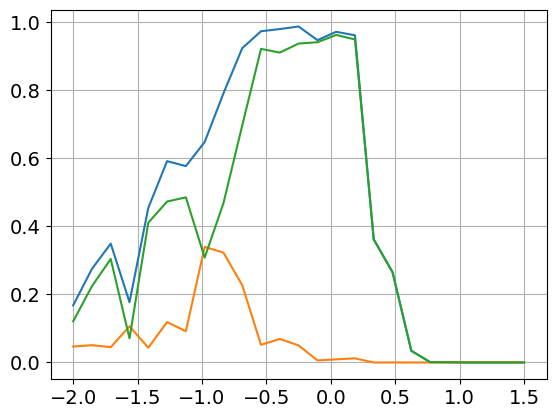

In [72]:
fig, ax = plt.subplots()
ax.plot(detunings / 1e6, 1 - res_batch.probabilities_final[:, 2, 14])
ax.plot(detunings / 1e6, res_batch.probabilities_final[:, 2, 20])
ax.plot(detunings / 1e6, res_batch.probabilities_final[:, 2, 35])
ax.grid()

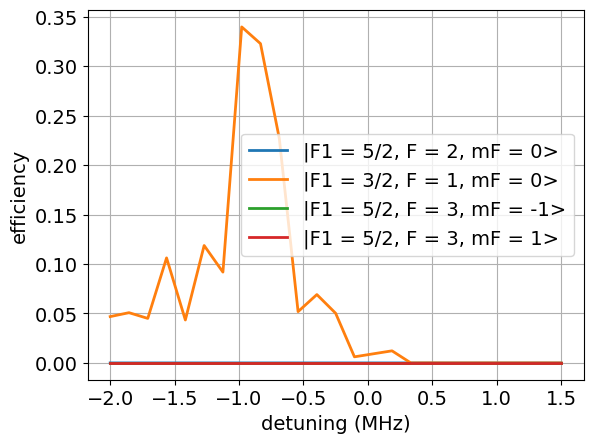

: 

In [ ]:
pop_monitor = np.array([r[-1] for r in res])
label_monitor = [
    s.transform_to_coupled().largest.state_string_custom(["F1", "F", "mF"])
    for s in monitor_states
]

fig, ax = plt.subplots()

ax.plot(detunings / 1e6, pop_monitor, lw=2, label=label_monitor)

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend()
ax.grid()

In [ ]:
pop_detected = np.array([r[-2] for r in res])
pop_detected += np.array([r[-1][-2] for r in res])
pop_detected += np.array([r[-1][-1] for r in res])

: 

: 

: 

: 

In [ ]:
pop_monitor = np.array([r[-1] for r in res])
pop_transferred = np.array([r[-2] for r in res]) + pop_monitor.sum(axis=1)

: 

: 

: 

: 

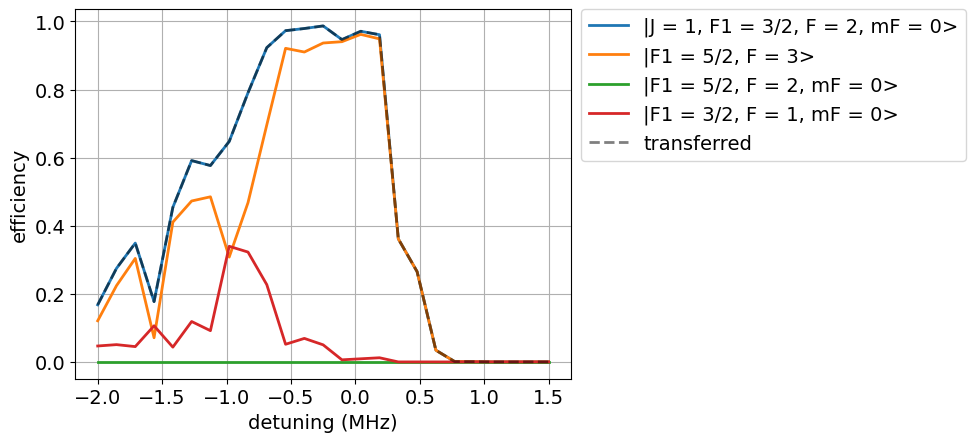

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    detunings / 1e6,
    [1 - r[-3] for r in res],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot(detunings / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(detunings / 1e6, pop_monitor[:, :-2], lw=2, label=label_monitor[:-2])

ax.plot(
    detunings / 1e6, pop_transferred, "k", lw=2, ls="--", alpha=0.5, label="transferred"
)


ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
paper_offset = muW_freq_2 - common_offset

: 

: 

: 

: 

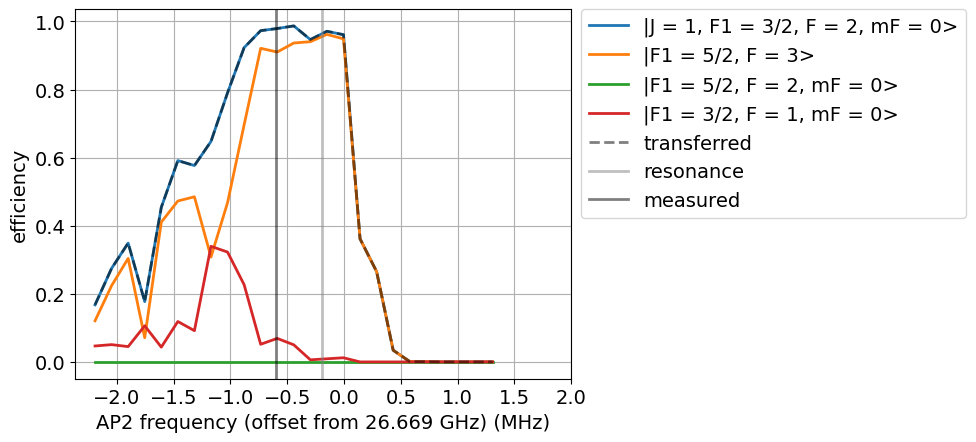

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    [1 - r[-3] for r in res],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot((detunings + paper_offset) / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor[:, :-2],
    lw=2,
    label=label_monitor[:-2],
)

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_transferred,
    "k",
    lw=2,
    ls="--",
    alpha=0.5,
    label="transferred",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
import pandas as pd

initial_pop = [r[-3] for r in res]
final_pop = [r[-2] for r in res]

df = pd.DataFrame(
    {
        "frequency [MHz]": (detunings + muW_freq_2) / 1e6,
        "detuning [MHz]": detunings / 1e6,
        "pop initial": initial_pop,
        "pop final": final_pop,
        label_monitor[0]: pop_monitor[:, 0],
        label_monitor[1]: pop_monitor[:, 1],
        label_monitor[2]: pop_monitor[:, 2],
        label_monitor[3]: pop_monitor[:, 3],
    }
)

df.to_csv(path_data / "SPA2_power_scan_simulation_paper_comparison.csv", index=False)


: 

: 

: 

: 

In [ ]:
detunings = np.linspace(-2e6, 1e6, num=15)

res_power = []
for power_spa2 in [5e-6, 1e-5, 2e-5, 5e-5]:
    res = Parallel(n_jobs=nr_cores, verbose=1)(
        delayed(run_simulation)(
            power_spa2=power_spa2,
            bg_fraction=1 / 35,
            freq_spa2=detuning + muW_freq_2,
            v_forward=184.0,
            initial_state_idx=2,  # J1_triplet_0
            initial_states_approx=initial_states_approx,
            target_state=J2_triplet_0,
            monitor_states=monitor_states,
        )
        for detuning in detunings
    )
    res_power.append((power_spa2, res))

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   21.4s remaining:    5.3s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   21.5s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   22.3s remaining:    5.5s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   22.4s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   23.2s remaining:    5.7s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   23.2s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   23.3s remaining:    5.7s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   23.4s finished


: 

: 

: 

: 

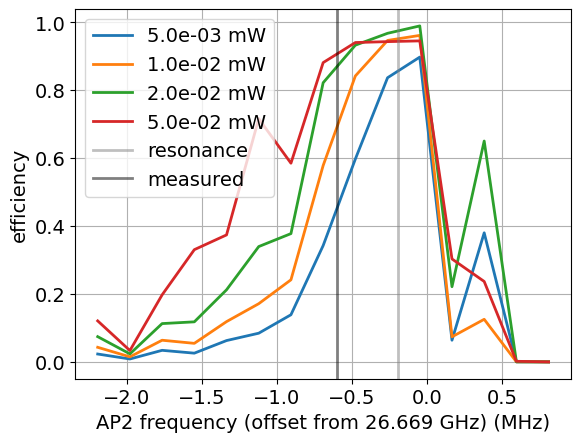

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

for power_spa2, res in res_power:
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])

    ax.plot(
        (detunings + paper_offset) / 1e6,
        pop_detected,
        lw=2,
        label=f"{power_spa2 * 1e3:.1e} mW",
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

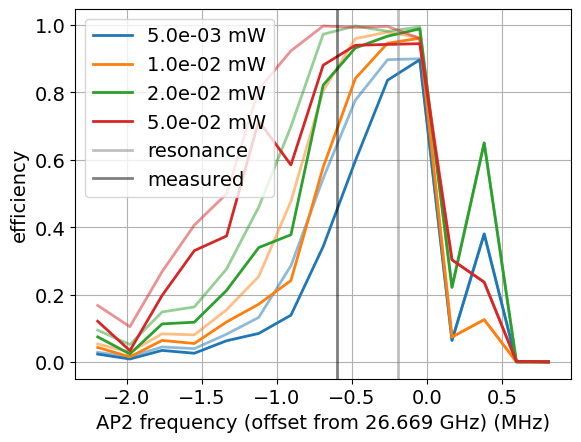

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

for power_spa2, res in res_power:
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        pop_detected,
        lw=2,
        label=f"{power_spa2 * 1e3:.1e} mW",
    )

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        [1 - r[-3] for r in res],
        lw=2,
        color=clines[0].get_color(),
        alpha=0.5,
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

## No BG

In [ ]:
detunings = np.linspace(-2e6, 1e6, 25)


res = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation)(
        power_spa2=5e-5,
        bg_fraction=0,
        freq_spa2=detuning + muW_freq_2,
        v_forward=184.0,
        initial_state_idx=2,  # J1_triplet_0
        initial_states_approx=initial_states_approx,
        target_state=J2_triplet_0,
        monitor_states=monitor_states,
    )
    for detuning in detunings
)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   36.6s finished


: 

: 

: 

: 

In [ ]:
paper_offset = muW_freq_2 - common_offset

: 

: 

: 

: 

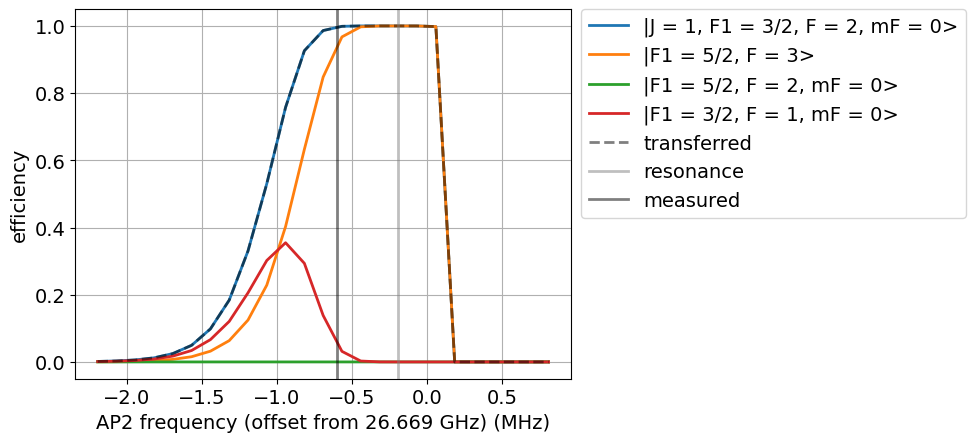

: 

: 

: 

: 

In [ ]:
pop_detected = np.array([r[-2] for r in res])
pop_detected += np.array([r[-1][-2] for r in res])
pop_detected += np.array([r[-1][-1] for r in res])

pop_monitor = np.array([r[-1] for r in res])

pop_transferred = np.array([r[-2] for r in res]) + pop_monitor.sum(axis=1)

fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    [1 - r[-3] for r in res],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot((detunings + paper_offset) / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor[:, :-2],
    lw=2,
    label=label_monitor[:-2],
)

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_transferred,
    "k",
    lw=2,
    ls="--",
    alpha=0.5,
    label="transferred",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
detunings = np.linspace(-2e6, 1e6, num=15)

res_power = []
for power_spa2 in [5e-6, 1e-5, 2e-5, 5e-5]:
    res = Parallel(n_jobs=nr_cores, verbose=1)(
        delayed(run_simulation)(
            power_spa2=power_spa2,
            bg_fraction=0.0,
            freq_spa2=detuning + muW_freq_2,
            v_forward=184.0,
            initial_state_idx=2,  # J1_triplet_0
            initial_states_approx=initial_states_approx,
            target_state=J2_triplet_0,
            monitor_states=monitor_states,
        )
        for detuning in detunings
    )
    res_power.append((power_spa2, res))

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   23.4s remaining:    5.8s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   23.5s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   24.0s remaining:    5.9s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   24.1s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   24.7s remaining:    6.1s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   24.8s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  15 | elapsed:   24.5s remaining:    6.0s
[Parallel(n_jobs=10)]: Done  15 out of  15 | elapsed:   24.5s finished


: 

: 

: 

: 

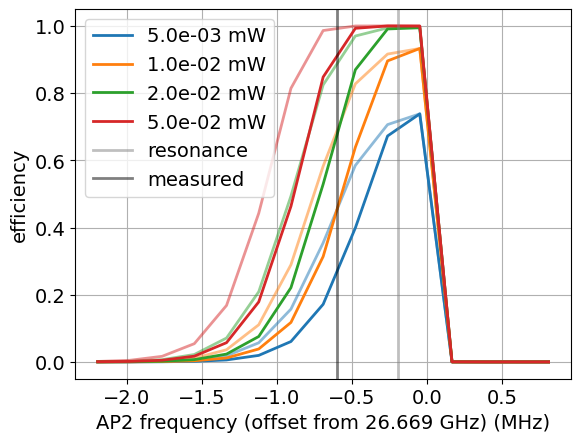

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

for power_spa2, res in res_power:
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        pop_detected,
        lw=2,
        label=f"{power_spa2 * 1e3:.1e} mW",
    )

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        [1 - r[-3] for r in res],
        lw=2,
        color=clines[0].get_color(),
        alpha=0.5,
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

## BG RHS only

In [ ]:
#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p = p_z
P_R = lambda R: p / np.sqrt(np.sum(p**2))


pol_bg = Polarization(P_R)

#### Intensity profile:
lims = [
    (-1, 1),
    (-1, 1),
    (-1e-5, 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

: 

: 

: 

: 

In [ ]:
def run_simulation(
    power_spa2: float,
    bg_fraction: float,
    freq_spa2: float,
    v_forward: float,
    initial_state_idx: int,
    initial_states_approx: list[states.UncoupledState],
    target_state: states.UncoupledState | list[states.UncoupledState],
    monitor_states: list[states.UncoupledState] = [],
    N_steps=10_000,
) -> tuple[float, float, float, float, float, float, list[float]]:
    """
    Runs the simulation for one value of power and finds the probability of ending up in the target state.
    """

    mf12.set_frequency(freq_spa2)
    mf12_bg.set_frequency(freq_spa2)

    # set powers & intensities
    mf12.set_power(power_spa2)
    mf12_bg.intensity.intensity = (
        mf12.intensity.I_R(np.array([0.00, 0, 0.0254 * 1.125])) * bg_fraction
    )

    # Run the simulator
    microwave_fields = [mf12, mf12_bg]

    # # trajectories
    trajectory.Vini[-1] = v_forward

    # pickle problem occurs here
    simulator = Simulator(
        trajectory,
        electric_field,
        magnetic_field,
        initial_states_approx,
        hamiltonian,
        microwave_fields,
    )

    result = simulator.run(N_steps=N_steps)

    # Determine probability to be in initial state
    prob_ini = float(
        result.get_state_probability(
            result.initial_states[initial_state_idx],
            initial_state=result.initial_states[initial_state_idx],
        )[-1]
    )

    # Determine probability to be in target state
    if isinstance(target_state, states.UncoupledState):
        target_state = [target_state]
    prob_fin = 0.0
    for ts in target_state:
        prob_fin += float(
            result.get_state_probability(
                ts, initial_state=result.initial_states[initial_state_idx]
            )[-1]
        )

    prob_monitor_states = []
    for monitor_state in monitor_states:
        prob_monitor_states.append(
            float(
                result.get_state_probability(
                    monitor_state,
                    initial_state=result.initial_states[initial_state_idx],
                )[-1]
            )
        )

    return (
        power_spa2,
        bg_fraction,
        freq_spa2,
        v_forward,
        prob_ini,
        prob_fin,
        prob_monitor_states,
    )


: 

: 

: 

: 

In [ ]:
detunings = np.linspace(-2e6, 1e6, 25)

res = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation)(
        power_spa2=3e-5,
        bg_fraction=1 / 15,
        freq_spa2=detuning + muW_freq_2,
        v_forward=184.0,
        initial_state_idx=2,  # J1_triplet_0
        initial_states_approx=initial_states_approx,
        target_state=J2_triplet_0,
        monitor_states=monitor_states,
    )
    for detuning in detunings
)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   38.0s finished


: 

: 

: 

: 

In [ ]:
pop_detected = np.array([r[-2] for r in res])
pop_detected += np.array([r[-1][-2] for r in res])
pop_detected += np.array([r[-1][-1] for r in res])

: 

: 

: 

: 

In [ ]:
pop_monitor = np.array([r[-1] for r in res])
pop_transferred = np.array([r[-2] for r in res]) + pop_monitor.sum(axis=1)

: 

: 

: 

: 

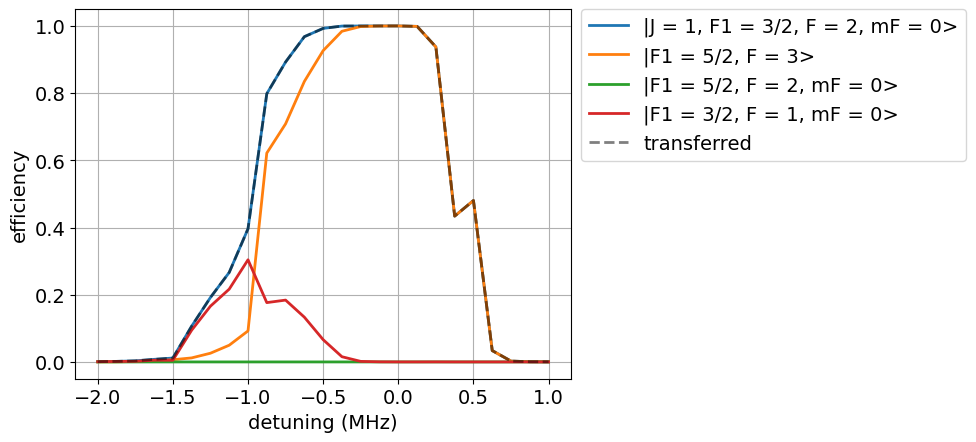

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    detunings / 1e6,
    [1 - r[-3] for r in res],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot(detunings / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(detunings / 1e6, pop_monitor[:, :-2], lw=2, label=label_monitor[:-2])

ax.plot(
    detunings / 1e6, pop_transferred, "k", lw=2, ls="--", alpha=0.5, label="transferred"
)


ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
paper_offset = muW_freq_2 - common_offset

: 

: 

: 

: 

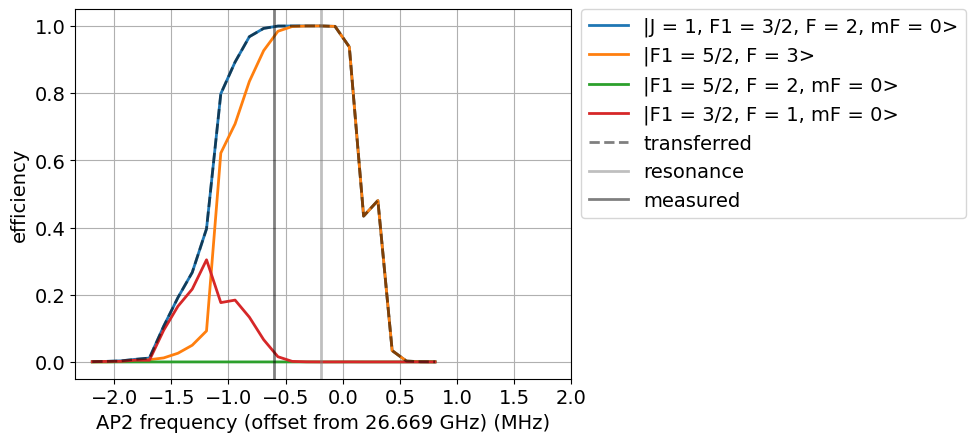

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    [1 - r[-3] for r in res],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot((detunings + paper_offset) / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor[:, :-2],
    lw=2,
    label=label_monitor[:-2],
)

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_transferred,
    "k",
    lw=2,
    ls="--",
    alpha=0.5,
    label="transferred",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
import pandas as pd

initial_pop = [r[-3] for r in res]
final_pop = [r[-2] for r in res]

df = pd.DataFrame(
    {
        "frequency [MHz]": (detunings + muW_freq_2) / 1e6,
        "detuning [MHz]": detunings / 1e6,
        "pop initial": initial_pop,
        "pop final": final_pop,
        label_monitor[0]: pop_monitor[:, 0],
        label_monitor[1]: pop_monitor[:, 1],
        label_monitor[2]: pop_monitor[:, 2],
        label_monitor[3]: pop_monitor[:, 3],
    }
)

df.to_csv(
    path_data / "SPA2_power_scan_simulation_bg_rhs_paper_comparison.csv", index=False
)


: 

: 

: 

: 

## Constant BG intensity velocity averaged

In [ ]:
#### Intensity profile:
lims = [
    (-1, 1),
    (-1, 1),
    (-1, 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

: 

: 

: 

: 

In [ ]:
velocities = np.linspace(184 - 16 * 2, 184 + 16 * 2, 11)

detunings = np.linspace(-2e6, 1.5e6, 25)

res_velocity = []
for vel in velocities:
    res = Parallel(n_jobs=nr_cores, verbose=1)(
        delayed(run_simulation)(
            power_spa2=3e-5,
            bg_fraction=1 / 25,
            freq_spa2=detuning + muW_freq_2,
            v_forward=vel,
            initial_state_idx=2,  # J1_triplet_0
            initial_states_approx=initial_states_approx,
            target_state=J2_triplet_0,
            monitor_states=monitor_states,
        )
        for detuning in detunings
    )
    res_velocity.append((vel, res))

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   40.2s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   39.1s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   38.6s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   37.9s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   37.5s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out of  25 | elapsed:   37.4s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  25 out

: 

: 

: 

: 

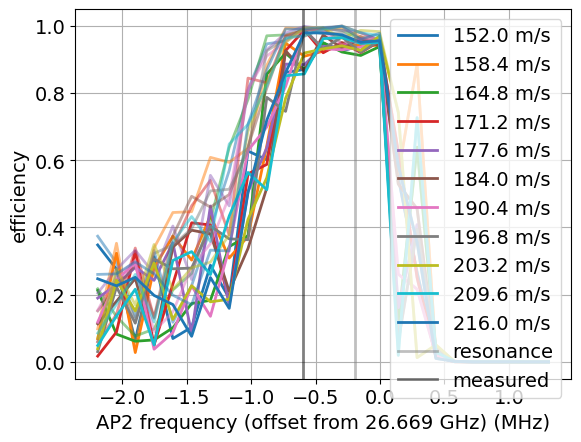

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

for vel, res in res_velocity:
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        pop_detected,
        lw=2,
        label=f"{vel:.1f} m/s",
    )

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        [1 - r[-3] for r in res],
        lw=2,
        color=clines[0].get_color(),
        alpha=0.5,
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

In [ ]:
appearance = np.zeros_like(detunings)
removal = np.zeros_like(detunings)
for vel, res in res_velocity:
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])
    appearance += pop_detected / len(velocities)
    removal += np.array([1 - r[-3] for r in res]) / len(velocities)


: 

: 

: 

: 

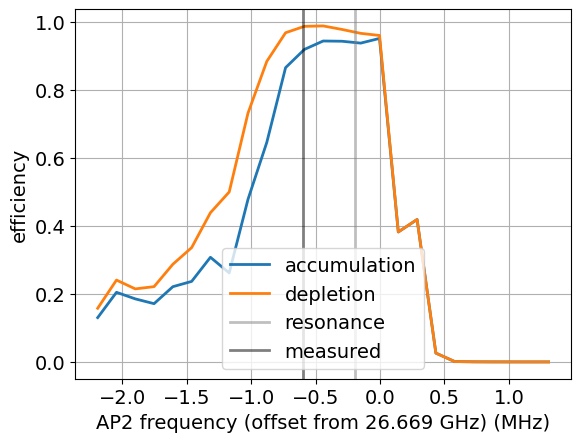

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot((detunings + paper_offset) / 1e6, appearance, lw=2, label="accumulation")

ax.plot(
    (detunings + paper_offset) / 1e6,
    removal,
    lw=2,
    label="depletion",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

In [ ]:
v0 = 184.0
sigma_v = 16.0
weights = np.exp(-0.5 * ((velocities - v0) / sigma_v) ** 2)
weights /= weights.sum()

: 

: 

: 

: 

In [ ]:
appearance = np.zeros_like(detunings)
removal = np.zeros_like(detunings)
for idv, (vel, res) in enumerate(res_velocity):
    pop_detected = np.array([r[-2] for r in res])
    pop_detected += np.array([r[-1][-2] for r in res])
    pop_detected += np.array([r[-1][-1] for r in res])
    appearance += pop_detected * weights[idv]
    removal += np.array([1 - r[-3] for r in res]) * weights[idv]


: 

: 

: 

: 

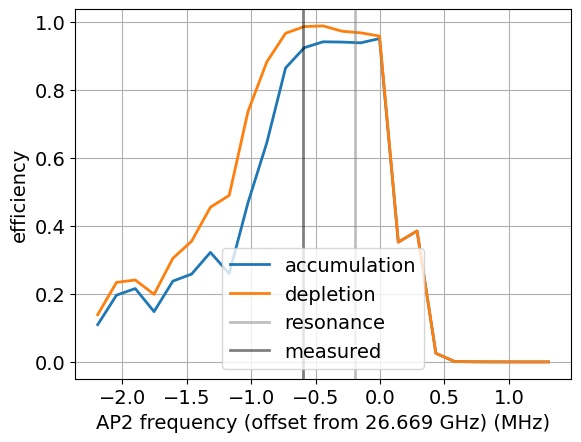

: 

: 

: 

: 

In [ ]:
fig, ax = plt.subplots()

ax.plot((detunings + paper_offset) / 1e6, appearance, lw=2, label="accumulation")

ax.plot(
    (detunings + paper_offset) / 1e6,
    removal,
    lw=2,
    label="depletion",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

: 

: 

: 

: 